In [ ]:
from IPython.core.display import HTML
HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600;700&family=Inter:wght@400;500&display=swap');
body,p,li,div{font-family:'Inter',sans-serif}
body{counter-reset:h2counter}
.usecase-header-bar,.usecase-title,.usecase-section-heading,.usecase-sub-section-heading,.usecase-sub-sub-section-heading,.usecase-unnumbered-heading{font-family:'Poppins',sans-serif}
.usecase-header-bar{padding:16px 20px;background-color:#059669;color:#fff;border-radius:6px 6px 0 0}
.usecase-title{font-size:1.9em;font-weight:800}
.usecase-details{padding-left:20px;padding-bottom:8px;padding-top:8px;font-size:1.1em;color:#121212}
.usecase-section-heading,.usecase-unnumbered-heading{font-weight:700;font-size:1.35em;color:#059669;padding:14px 4px 6px 4px;border-bottom:3px solid #2DBE6C;margin-top:10px}
.usecase-section-heading::before{content:none!important}
.usecase-sub-section-heading{font-weight:600;font-size:1.15em;color:#059669;margin-top:8px}
.usecase-sub-section-heading::before{content:none!important}
.usecase-sub-sub-section-heading{font-weight:500;font-size:1.05em;color:#059669;margin-top:6px}
.usecase-sub-sub-section-heading::before{content:none!important}
.usecase-body{font-size:1em;color:#121212;line-height:1.6;margin-bottom:8px}
.usecase-list{line-height:1.7}
.usecase-list ul,.usecase-list ol{padding-left:24px;margin-top:8px;margin-bottom:12px}
.usecase-list li{margin-bottom:6px}
.usecase-datasets{background-color:rgba(5,150,105,.06);border-left:4px solid #059669;padding:12px 20px;border-radius:0 4px 4px 0;margin-top:12px}
.usecase-datasets ul{margin-top:8px;margin-bottom:8px}
.usecase-contents a,.usecase-datasets a{color:#059669;text-decoration:none}
.usecase-datasets a{font-weight:500}
.usecase-contents a:hover,.usecase-datasets a:hover{text-decoration:underline}
.usecase-contents{line-height:1.9;padding-left:20px}
</style>
""")

<div class="usecase-header-bar">
<div class="usecase-title">UC00139: Optimisation of Outdoor Fitness Activities in Melbourne</div>
</div>

<div class="usecase-details">
<b>Authored by:</b> Ananya Krishnan<br>
<b>Date Created:</b> Trimester 2, 2026<br>
<b>Time to Complete:</b> 90 minutes<br>
<b>Level:</b> Intermediate<br>
<b>Pre-requisite Skills:</b> Python, Pandas, GeoPandas, geospatial analysis concepts, basic geospatial analysis concepts
</div>

<div class="usecase-unnumbered-heading">Scenario</div>
<div class="usecase-body">
The City of Melbourne provides numerous parks, playgrounds, walking tracks and open spaces that encourage outdoor fitness activities. However, choosing suitable locations for exercise depends on factors including pedestrian activity, accessibility, tree canopy coverage and the availability of amenities such as drinking fountains, seating and public toilets.
<br><br>
In this use case, you will act as a data analyst working with Melbourne Open Data. By combining multiple public datasets and applying geospatial analysis techniques, you will identify suitable outdoor fitness locations and generate insights that can support urban planning and improve community wellbeing.
</div>

<div class="usecase-unnumbered-heading">What this usecase will teach you</div>
<div class="usecase-body">This use case demonstrates how multiple public datasets can be combined to assess the accessibility of outdoor fitness environments and produce evidence-based spatial insights.</div>
<div class="usecase-list">
<ul>
<li>Retrieve and inspect datasets from the Melbourne Open Data API.</li>
<li>Clean, transform and combine datasets for geospatial analysis.</li>
<li>Calculate nearest-feature distances using a projected coordinate system.</li>
<li>Develop accessibility scores and categories from spatial measurements.</li>
<li>Visualise and interpret accessibility results using charts and maps.</li>
</ul>
</div>

<div class="usecase-unnumbered-heading">Background</div>
<div class="usecase-body">
Outdoor fitness spaces can support healthy and active lifestyles when people can conveniently access suitable open spaces, amenities and shaded environments. This analysis combines pedestrian locations with information about parks, playgrounds, pedestrian networks, public amenities and tree canopy to assess accessibility across the study area.
<br><br>
The analysis uses geospatial preprocessing and nearest-feature distance calculations to create component accessibility scores. These scores are combined into an overall MOP Accessibility Score to identify locations with high, moderate or low accessibility.
</div>

<div class="usecase-unnumbered-heading">Data Sets</div>
<div class="usecase-datasets">
<ul>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-sensor-locations/">Pedestrian Counting System – Sensor Locations</a></li>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-past-hour-counts-per-minute/">Pedestrian Counting System – Past Hour Counts per Minute</a></li>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/trees-with-species-and-dimensions-urban-forest/">Urban Forest – Trees with Species and Dimensions</a></li>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/playgrounds/">Playgrounds</a></li>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-network/">Pedestrian Network</a></li>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/drinking-fountains/">Drinking Fountains</a></li>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/public-toilets/">Public Toilets</a></li>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/street-furniture-including-bollards-bicycle-rails-bins-drinking-fountains-horse-/">Street Furniture / Public Assets</a></li>
<li><a href="https://data.melbourne.vic.gov.au/explore/dataset/tree-canopies-public-realm-2018-urban-forest/">Tree Canopies – Public Realm 2018</a></li>
</ul>
</div>
<div class="usecase-body">These datasets provide the pedestrian, open-space, amenity and environmental information required to calculate and interpret outdoor fitness accessibility.</div>

<div class="usecase-unnumbered-heading">Contents</div>
<div class="usecase-contents">
<ol>
<li><a href="#section-1">Import Required Libraries</a></li>
<li><a href="#section-2">Data Acquisition</a>
<ol>
<li><a href="#section-2-1">Explore the Datasets</a></li>
<li><a href="#section-2-2">Understand the Dataset Structure</a></li>
</ol>
</li>
<li><a href="#section-3">Data Cleaning and Pre-processing</a>
<ol>
<li><a href="#section-3-1">Cleaning Individual Datasets</a></li>
<li><a href="#section-3-2">Extracting Geographic Coordinates</a></li>
<li><a href="#section-3-3">Geospatial Data Processing</a></li>
</ol>
</li>
<li><a href="#section-4">Geospatial Accessibility Analysis</a>
<ol>
<li><a href="#section-4-1">Convert Geospatial Data to a Projected CRS</a></li>
<li><a href="#section-4-2">Open-Space Accessibility</a></li>
<li><a href="#section-4-3">Public Amenity Accessibility</a></li>
<li><a href="#section-4-4">Tree-Canopy Accessibility</a></li>
<li><a href="#section-4-5">Accessibility Scoring</a></li>
<li><a href="#section-4-6">Overall MOP Accessibility</a></li>
<li><a href="#section-4-7">Visualisation of Accessibility Results</a></li>
<li><a href="#section-4-8">Final MOP Accessibility Map</a></li>
</ol>
</li>
<li><a href="#section-5">Results and Findings</a>
<ol>
<li><a href="#section-5-1">Overall MOP Accessibility</a></li>
<li><a href="#section-5-2">Accessibility to Open Spaces</a></li>
<li><a href="#section-5-3">Accessibility to Public Amenities</a></li>
<li><a href="#section-5-4">Accessibility to Tree Canopy</a></li>
<li><a href="#section-5-5">Key Findings</a></li>
<li><a href="#section-5-6">Limitations</a></li>
</ol>
</li>
</ol>
</div>

<div id="section-1" class="usecase-section-heading"><b>Step 1: Import Required Libraries</b></div>

<div class="usecase-body">

This step imports the Python libraries required for the analysis. The selected libraries support data retrieval, tabular data preparation, geospatial processing, distance calculations and visualisation. Keeping the required tools together at the start of the notebook makes the workflow easier to reproduce and maintain.

The key libraries used include:

- **requests** – retrieves datasets from the Melbourne Open Data API.
- **pandas** – loads and manipulates tabular data.
- **GeoPandas** – performs geospatial data processing and spatial operations.
- **Shapely** – creates and manages geometric objects.
- **Matplotlib** – creates data visualisations.
</div>

In [ ]:
%pip install requests pandas numpy geopandas matplotlib

import requests
import pandas as pd
from io import StringIO
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

<div id="section-2" class="usecase-section-heading"><b>Step 2: Data Acquisition</b></div>

<div class="usecase-body">

This use case retrieves multiple datasets from the Melbourne Open Data platform using its public API. Each dataset provides information about different aspects of Melbourne's outdoor environment, including pedestrian activity, parks, playgrounds, public amenities, and tree canopy coverage.

A reusable function is created to download each dataset in CSV format and load it into a Pandas DataFrame. This approach makes the notebook reusable and ensures that the latest available data is analysed each time the notebook is executed.
</div>

In [ ]:
# parsing the dataset name and API key
def API_upload(link_dataset):

    # define API endpoints
    core_url= 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'
    # dataset_id= apiKey
    key= link_dataset
    format= 'csv'
    web_url= f'{core_url}{key}/exports/{format}'
    params={
        # similar to SQL's  queries
        'select': '*',      # selects all fields from dataset
        'timezone': 'UTC',  # setting desired time zone in return data
        'lang': 'en',       # specifies language preference of data being retrieved
        'limit': '-1',      # defines maximum number of records to return
    }
    # get request for retrieving response
    response= requests.get(web_url, params= params)
    if response.status_code == 200:
        url_content= response.content.decode('utf-8')                   # convert raw response in bytes into UTF-8 encoded string
        df_dataset= pd.read_csv(StringIO(url_content), delimiter= ';')  # parse the csv content into a pandas DataFrame
        print('\n', key, '\n', df_dataset)
        pd.set_option('display.max_columns', None)                      # exhibit all coloumns of the data set
        print('\nlength of above dataset=', len(df_dataset))            # length of dataset computed
        return df_dataset
    else:
        return (print(f'Error fetching data from {web_url}: {response.status_code}'))

# Pedestrian sensor locations
link_pedCount= 'pedestrian-counting-system-sensor-locations'
# Pedestrian counts per minute
link_countPm= 'pedestrian-counting-system-past-hour-counts-per-minute'
# Urban forest
link_urbanForest= 'trees-with-species-and-dimensions-urban-forest'
# Playgrounds
link_playground= 'playgrounds'
# Pedestrian network
link_pedTrack= 'pedestrian-network'
# Drinking fountains
link_drinkingFountains= 'drinking-fountains'
# Public washrooms
link_publicWashrooms= 'public-toilets'
# Public assets (including seats)
link_publicAsset= 'street-furniture-including-bollards-bicycle-rails-bins-drinking-fountains-horse-'
# Tree canopy
#link_treeCanopy= 'tree-canopies-2021-urban-forest'
link_treeCanopy= 'tree-canopies-public-realm-2018-urban-forest'

# download url 1.5 (Service 1.URL)

# loading the data via function 'API_upload()'-
# pedestrian counting system
df_pedFreq= API_upload(link_pedCount)
# pedestrian counting each minute
df_pedFreq_Pm= API_upload(link_countPm)
# urban forest in Melbourne
df_urbanForest= API_upload(link_urbanForest)
# playgrounds in Melbourne
df_playground= API_upload(link_playground)
# pedestrian network/track of Melbourne city
df_pedTrack= API_upload(link_pedTrack)
# drinking fountains in Melbourne city
df_drinkingFountains= API_upload(link_drinkingFountains)
# public washrooms in Melbourne city
df_publicWashroom= API_upload(link_publicWashrooms)
# public asset in Melbourne city
df_publicAsset= API_upload(link_publicAsset)
# tree canopies in Melbourne city
df_treeCanopy= API_upload(link_treeCanopy)








 pedestrian-counting-system-sensor-locations 
      location_id                       sensor_description sensor_name  \
0              3                        Melbourne Central    Swa295_T   
1              5                           Princes Bridge     PriNW_T   
2              9                   Southern Cross Station    Col700_T   
3             11  Docklands Waterfront City Building Side    WatCit_T   
4             12                                 New Quay      NewQ_T   
..           ...                                      ...         ...   
129          167     I-Hub 526 La Trobe Street (Crossing)    Lat526_T   
130          179             61-67 Power Street Southbank     Pow61_T   
131          182                          163 King Street   King163_T   
132          184                     124 Elizabeth Street    Eli124_T   
133          187   RMIT Building 22 - 330 Swanston Street    Swa330_T   

    installation_date                                               note  \

<div id="section-2-1" class="usecase-sub-section-heading"><b>Step 2.1: Explore the Datasets</b></div>

<div class="usecase-body">

This section checks the records returned from each source to confirm that the datasets have been retrieved successfully and to understand the type of information available before cleaning and analysis.
</div>

In [ ]:
# pedestrian counting system
dataset_pedPopulation= df_pedFreq.head(len(df_pedFreq))
print('\nSensor Location Dataset:\n', dataset_pedPopulation)

# pedestrian counting each minute
dataset_pedPopulation_Pm= df_pedFreq_Pm.head(len(df_pedFreq_Pm))
print('\nPedestrian Count Per Minute Dataset:\n', dataset_pedPopulation_Pm)

# urban forest in Melbourne
dataset_urbanForest= df_urbanForest.head(len(df_urbanForest))
print('\nUrban Forest Dataset:\n', dataset_urbanForest)

# playgrounds in Melbourne
dataset_playground= df_playground.head(len(df_playground))
print('\nPlayground Dataset:\n', dataset_playground)

# pedestrian network/track of Melbourne city
dataset_pedTrack= df_pedTrack.head(len(df_pedTrack))
print('\nPedestrian Track Dataset:\n', dataset_pedTrack)

# drinking fountains in Melbourne city
dataset_drinkingFountains= df_drinkingFountains.head(len(df_drinkingFountains))
print('\nDrinking Fountains Dataset:\n', dataset_drinkingFountains)

# public washrooms in Melbourne city
dataset_publicWashroom= df_publicWashroom.head(len(df_publicWashroom))
print('\nPublic Washroom Dataset:\n', dataset_publicWashroom)

# public asset in Melbourne city
dataset_publicAsset= df_publicAsset.head(len(df_publicAsset))
print('\nPublic Assets Dataset:\n', dataset_publicAsset)

# tree canopies in Melbourne city
dataset_treeCanopy= df_treeCanopy.head(len(df_treeCanopy))
print('\nTree Canopies Dataset:\n', dataset_treeCanopy)








Sensor Location Dataset:
      location_id                       sensor_description sensor_name  \
0              3                        Melbourne Central    Swa295_T   
1              5                           Princes Bridge     PriNW_T   
2              9                   Southern Cross Station    Col700_T   
3             11  Docklands Waterfront City Building Side    WatCit_T   
4             12                                 New Quay      NewQ_T   
..           ...                                      ...         ...   
129          167     I-Hub 526 La Trobe Street (Crossing)    Lat526_T   
130          179             61-67 Power Street Southbank     Pow61_T   
131          182                          163 King Street   King163_T   
132          184                     124 Elizabeth Street    Eli124_T   
133          187   RMIT Building 22 - 330 Swanston Street    Swa330_T   

    installation_date                                               note  \
0          2009-03-2

<div id="section-2-2" class="usecase-sub-section-heading"><b>Step 2.2: Understand the Dataset Structure</b></div>

<div class="usecase-body">

This section reviews columns, data types, summary statistics and missing values. These checks help identify inconsistencies or incomplete records that could affect the spatial analysis and determine what preprocessing is required.
</div>

In [ ]:
# Function to display summary information for a dataset
def explore_dataset(dataset, dataset_name):
    print("=" * 60)
    print(f"{dataset_name}")
    print("=" * 60)

    print("\nDataset Information:")
    dataset.info()

    print("\nDescriptive Statistics:")
    print(dataset.describe(include='all'))

    print("\nMissing Values:")
    print(dataset.isnull().sum())

    print("\n")


# Explore each dataset
explore_dataset(dataset_pedPopulation, "Sensor Location Dataset")
explore_dataset(dataset_pedPopulation_Pm, "Pedestrian Count Per Minute Dataset")
explore_dataset(dataset_urbanForest, "Urban Forest Dataset")
explore_dataset(dataset_playground, "Playground Dataset")
explore_dataset(dataset_pedTrack, "Pedestrian Network Dataset")
explore_dataset(dataset_drinkingFountains, "Drinking Fountains Dataset")
explore_dataset(dataset_publicWashroom, "Public Toilets Dataset")
explore_dataset(dataset_publicAsset, "Public Assets Dataset")
explore_dataset(dataset_treeCanopy, "Tree Canopy Dataset")

Sensor Location Dataset

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   location_id         134 non-null    int64  
 1   sensor_description  134 non-null    object 
 2   sensor_name         134 non-null    object 
 3   installation_date   133 non-null    object 
 4   note                38 non-null     object 
 5   location_type       134 non-null    object 
 6   status              134 non-null    object 
 7   direction_1         100 non-null    object 
 8   direction_2         100 non-null    object 
 9   latitude            134 non-null    float64
 10  longitude           134 non-null    float64
 11  location            134 non-null    object 
dtypes: float64(2), int64(1), object(9)
memory usage: 12.7+ KB

Descriptive Statistics:
        location_id                             sensor_description  \
count

<div id="section-3" class="usecase-section-heading"><b>Step 3: Data Cleaning and Pre-processing</b></div>

<div class="usecase-body">

This step prepares the source data for spatial analysis. Cleaning is required because datasets come from different sources and may use different field names, coordinate formats or record structures. The cleaned data is standardised so the relevant features can be compared consistently.
</div>

<div id="section-3-1" class="usecase-sub-section-heading"><b>3.1 Cleaning Individual Datasets</b></div>

<div class="usecase-body">

This section applies dataset-specific cleaning so that only records relevant to the accessibility analysis are retained. Invalid or incomplete records are removed where necessary, and relevant fields are selected for pedestrian locations, open spaces, amenities and tree canopy. This reduces noise and helps ensure that later distance calculations are based on usable spatial features.
</div>

In [ ]:
# sensor location API:
dataset_pedPopulation['installation_date']= pd.to_datetime(dataset_pedPopulation['installation_date'], errors='coerce')
dataset_pedPopulation.dropna(subset= ['installation_date'], inplace= True)
print('Cleaned Sensor Location Dataset:','\n', dataset_pedPopulation)
# urban forest in Melbourne:
dataset_park= dataset_urbanForest[dataset_urbanForest['located_in']!= 'Street']  # dataset for parks in Melbourne is retrieved. Dataset for streets is avoided considering safety for running.
print('Cleaned Urban Forest Dataset:','\n', dataset_park)
# drinking fountains in Melbourne city: ---> cleaning of data is not needed.
# public washrooms in Melbourne city: ---> cleaning of data is not needed.
# public asset in Melbourne city:
dataset_seats= dataset_publicAsset[dataset_publicAsset['asset_type']=='Seat']  # dataset for public seats is retrieved.
dataset_seats= dataset_seats.copy()  # explicitly copy is created before any modification is made. 'To avoid SettingWithCopyWarning: A value is trying to be set on a copy of a slice from a DataFrame' warning.
dataset_seats.dropna(subset=['coordinatelocation'],inplace= True)  # rows which has 'NAN' values for column 'coordinatelocation' are dropped from the table.
print('Cleaned Public Asset Dataset for Seats:','\n', dataset_seats)
# tree canopies in Melbourne city: ---> cleaning of data is not needed.




Cleaned Sensor Location Dataset: 
      location_id                       sensor_description sensor_name  \
0              3                        Melbourne Central    Swa295_T   
1              5                           Princes Bridge     PriNW_T   
2              9                   Southern Cross Station    Col700_T   
3             11  Docklands Waterfront City Building Side    WatCit_T   
4             12                                 New Quay      NewQ_T   
..           ...                                      ...         ...   
129          167     I-Hub 526 La Trobe Street (Crossing)    Lat526_T   
130          179             61-67 Power Street Southbank     Pow61_T   
131          182                          163 King Street   King163_T   
132          184                     124 Elizabeth Street    Eli124_T   
133          187   RMIT Building 22 - 330 Swanston Street    Swa330_T   

    installation_date                                               note  \
0          2

<div id="section-3-2" class="usecase-sub-section-heading"><b>3.2 Extracting Geographic Coordinates</b></div>

<div class="usecase-body">

This section extracts latitude and longitude from the source coordinate fields. Separating the coordinates allows each record to be represented as a point and provides the spatial inputs needed for mapping, nearest-feature analysis and distance calculations.
</div>

In [ ]:
# function to split a geolocation co-ordinate into latitude and longitude.
def geoLocSplit(dataset,dataset_loc):
    if 'latitude' in dataset.columns:  # verify if latitude and longitude column exists, if yes then drop them.
        dataset.drop(columns=['latitude','longitude'], inplace=True)
    # transform string 'geo_point_2d'/'coordinatelocation' into a list of floats.
    dataset_loc= dataset_loc.apply(lambda x: [float(i) for i in x.split(",")] if isinstance(x,str) else [float('nan'),float('nan')])
    # split the column 'geo_point_2d'/'coordinatelocation' into latitude and longitude columns.
    coordinate_split= pd.DataFrame(dataset_loc.to_list(), columns=['latitude', 'longitude'])
    # concatenate new columns with the original data frame.
    dataset= pd.concat([dataset.reset_index(drop=True),coordinate_split.reset_index(drop=True)], axis=1)
    return dataset

# playgrounds in Melbourne ---> Open-Space
dataset_playground= geoLocSplit(dataset_playground,dataset_playground['geo_point_2d'])
print('Geo-coordinates of Playground Dataset:','\n', dataset_playground)
# pedestrian network/track of Melbourne city ---> Open-Space
dataset_pedTrack= geoLocSplit(dataset_pedTrack,dataset_pedTrack['geo_point_2d'])
print('Geo-coordinates of Pedestrian Track Dataset:','\n', dataset_pedTrack)

# public seat in Melbourne city ---> Amenities
dataset_seats= geoLocSplit(dataset_seats,dataset_seats['coordinatelocation'])
print('Geo-coordinates of Seats Dataset:','\n', dataset_seats)

# tree canopies in Melbourne city ---> Urban Canopies
dataset_treeCanopy= geoLocSplit(dataset_treeCanopy,dataset_treeCanopy['geo_point_2d'])
print('Geo-coordinates of Tree Canopies Dataset:','\n', dataset_treeCanopy)






Geo-coordinates of Playground Dataset: 
                                geo_point_2d  \
0    -37.79980317243133, 144.94146553497296   
1     -37.79003673843191, 144.9256728627734   
2    -37.82611400247897, 144.96163469344134   
3   -37.781221527129574, 144.96214347994342   
4   -37.796615304958806, 144.92060508965284   
5    -37.818149015388066, 144.9712309067726   
6    -37.79542804645323, 144.92088329716032   
7     -37.8218009873152, 144.94722750144075   
8     -37.8020962906074, 144.97067458905988   
9    -37.797285033377186, 144.9739866829798   
10    -37.80284131718294, 144.9626564799592   
11    -37.8095257090171, 144.95471867901864   
12   -37.82307176194582, 144.94158310181788   
13   -37.79520740161526, 144.96970314493564   
14    -37.79616817586979, 144.9267597762389   
15   -37.79652622815778, 144.95277288002004   
16    -37.81158137797367, 144.9865706304634   
17  -37.840668223257225, 144.98402897622898   
18   -37.79319152147504, 144.93241661314613   
19  -37.79019168437

<div class="usecase-body">
This step standardises the coordinate column names across the public washroom and seating datasets. Using a consistent field name makes the datasets easier to combine and process during the geospatial analysis.
</div>

In [ ]:
# Standardise coordinate column names for merging and spatial processing
dataset_publicWashroom.rename(
    columns={'location': 'co_ordinates'},
    inplace=True
)

dataset_seats.rename(
    columns={'coordinatelocation': 'co_ordinates'},
    inplace=True
)

<div class="usecase-body">
This step combines the pedestrian population datasets using the common <code>location_id</code> field. An outer merge is used because the datasets contain different numbers of records and may not have matching entries for every location. Retaining records from both datasets helps preserve the available pedestrian information for subsequent analysis.
</div>

In [ ]:
# Merge pedestrian datasets using the common location_id field.
# An outer join retains records from both datasets.
merged_footTraffic = pd.merge(
    dataset_pedPopulation,
    dataset_pedPopulation_Pm,
    on='location_id',
    how='outer'
)

print("Merged Foot Traffic:\n", merged_footTraffic)

Merged Foot Traffic:
         location_id            sensor_description sensor_name  \
0                 1    Bourke Street Mall (North)    Bou292_T   
1                 1    Bourke Street Mall (North)    Bou292_T   
2                 1    Bourke Street Mall (North)    Bou292_T   
3                 1    Bourke Street Mall (North)    Bou292_T   
4                 1    Bourke Street Mall (North)    Bou292_T   
...             ...                           ...         ...   
755594          209  Flinders Underpass - Walkway      FliS_T   
755595          209  Flinders Underpass - Walkway      FliS_T   
755596          209  Flinders Underpass - Walkway      FliS_T   
755597          209  Flinders Underpass - Walkway      FliS_T   
755598          209  Flinders Underpass - Walkway      FliS_T   

       installation_date                 note location_type status  \
0             2009-03-24                  NaN       Outdoor      A   
1             2009-03-24                  NaN       Outdo

<div id="section-3-3" class="usecase-sub-section-heading"><b>3.3 Geospatial Data Processing</b></div>

<div class="usecase-body">

This section converts the cleaned location data into GeoDataFrames with point geometry and a consistent CRS. Combining the relevant open-space and amenity sources creates a single spatial layer for each accessibility component. These preparations allow nearest-feature distances to be calculated consistently between pedestrian locations and surrounding features.
</div>

In [ ]:
# function is to create geoDataFrame  where each row is associated with a spatial geometry (Point).
def processed_geoData(df, lon_attr, lat_attr):                          # consider longitude and latitude attributes.
    df= df.copy()                                                       # '.copy()'- copy original data frame before inplace modification.
    df.dropna(subset=[lon_attr, lat_attr], inplace=True)                # removing rows where longitude and latitude columns have missing values.
    df['geometry']= gpd.points_from_xy(df[lon_attr],df[lat_attr])       # the new column 'geometry' stores these point objects enabling geospatial analysis.
    gdf= gpd.GeoDataFrame(df, geometry= 'geometry', crs= "EPSG:4326")   # converts Pandas DataFrame (df) into a GeoPandas GeoDataFrame.  The variable 'crs' specifies the Coordinate Reference System (CRS) for the GeoDataFrame.
    return gdf                                                          # returns newly created GeoDataFrame with spatial information.

# geospatial data from pedestrian dataset for pre-processing.
pedGeo_data= processed_geoData(merged_footTraffic, 'longitude', 'latitude')
# print("\nPedestrian geo-spatial data\n",pedGeo_data)  #---> testing if pedestrian geospatial data is retrieved along with entire dataset.
geoPed_data= pedGeo_data[['latitude','longitude','geometry']]
print("\nPedestrian geo-spatial data\n",geoPed_data)  #---> testing if pedestrian geospatial data is retrieved.

# geospatial data from open-space datasets for pre-processing.
parkGeo_data= processed_geoData(dataset_park, 'longitude','latitude')
print("\nPark geo-spatial data\n",parkGeo_data)    #---> testing if park geospatial data is retrieved along with entire dataset.
playgroundGeo_data= processed_geoData(dataset_playground, 'longitude','latitude')
print("\nPlayground geo-spatial data\n",playgroundGeo_data)    #---> testing if playground geospatial data is retrieved along with entire dataset.
trackGeo_data= processed_geoData(dataset_pedTrack, 'longitude','latitude')
print("\nTrack geo-spatial data\n",trackGeo_data)    #---> testing if pedestrian track geospatial data is retrieved along with entire dataset.
openSpace_geoData= pd.concat([parkGeo_data[['latitude','longitude','geometry']],playgroundGeo_data[['latitude','longitude','geometry']],trackGeo_data[['latitude','longitude','geometry']]], axis=1, keys=['park','playground','track'])  # keys attribute is to assign a hierarichal (multi-level) column index to avoid conflicts. That is, to handle various columns of same name in various data frames.
print("\nOpen-space geo-spatial data\n",openSpace_geoData)  #---> testing if open-space geospatial data is retrieved.

# geospatial data from aminities datasets for pre-processing.

# Rename public washroom columns to match processed_geoData function
dataset_publicWashroom = dataset_publicWashroom.rename(
    columns={
        'lat': 'latitude',
        'lon': 'longitude'
    }
)

fountainGeo_data = processed_geoData(
    dataset_drinkingFountains,
    'longitude',
    'latitude'
)

print("\nDrinking fountains geo-spatial data\n", fountainGeo_data)
# ---> testing if fountain geospatial data is retrieved along with entire dataset.


washroomGeo_data = processed_geoData(
    dataset_publicWashroom,
    'longitude',
    'latitude'
)

print("\nPublic washroom geo-spatial data\n", washroomGeo_data)
# ---> testing if public washroom geospatial data is retrieved along with entire dataset.


seatsGeo_data = processed_geoData(
    dataset_seats,
    'longitude',
    'latitude'
)

print("\nPublic seats geo-spatial data\n", seatsGeo_data)
# ---> testing if public seats geospatial data is retrieved along with entire dataset.


amenities_geoData = pd.concat(
    [
        fountainGeo_data[['latitude','longitude','geometry']],
        washroomGeo_data[['latitude','longitude','geometry']],
        seatsGeo_data[['latitude','longitude','geometry']]
    ],
    axis=1,
    keys=[
        'drinking-fountains',
        'public-washrooms',
        'public-seats'
    ]
)

print("\nAmenities geo-spatial data\n", amenities_geoData)
# ---> testing if amenities geospatial data is retrieved.


# geospatial data from tree canopy datasets for pre-processing.

treeCanopyGeo_data = processed_geoData(
    dataset_treeCanopy,
    'longitude',
    'latitude'
)

print("\nTree canopy geo-spatial data\n", treeCanopyGeo_data)
# ---> testing if tree canopy geospatial data is retrieved along with entire dataset.


# eliminate the duplicate geospatial data for pedestrian, open-space, amenities, to avoid redundancy of geo-data.

geoPed_data = geoPed_data.drop_duplicates()

print("\nRequired Pedestrian geo-spatial data\n", geoPed_data)


openSpace_geoData = openSpace_geoData.drop_duplicates()

print("\nRequired Open-space geo-spatial data\n", openSpace_geoData)


amenities_data = amenities_geoData.drop_duplicates()

print("\nRequired Amenities geo-spatial data\n", amenities_data)


treeCanopy_data = treeCanopyGeo_data.drop_duplicates()

print("\nRequired Tree-canopy geo-spatial data\n", treeCanopy_data)






Pedestrian geo-spatial data
          latitude   longitude                     geometry
0      -37.813494  144.965153  POINT (144.96515 -37.81349)
1      -37.813494  144.965153  POINT (144.96515 -37.81349)
2      -37.813494  144.965153  POINT (144.96515 -37.81349)
3      -37.813494  144.965153  POINT (144.96515 -37.81349)
4      -37.813494  144.965153  POINT (144.96515 -37.81349)
...           ...         ...                          ...
755594 -37.819090  144.965497   POINT (144.9655 -37.81909)
755595 -37.819090  144.965497   POINT (144.9655 -37.81909)
755596 -37.819090  144.965497   POINT (144.9655 -37.81909)
755597 -37.819090  144.965497   POINT (144.9655 -37.81909)
755598 -37.819090  144.965497   POINT (144.9655 -37.81909)

[744124 rows x 3 columns]

Park geo-spatial data
         com_id          common_name           scientific_name        genus  \
19     1023282  Smooth-barked apple         Angophora costata    Angophora   
20     1023283  Smooth-barked apple         Angophora c

<div id="section-4" class="usecase-section-heading"><b>Step 4: Geospatial Accessibility Analysis</b></div>

<div class="usecase-body">

This step measures the spatial accessibility of open spaces, public amenities and tree canopy around each pedestrian location. Nearest-feature distances are calculated in a projected CRS and then converted into rule-based component scores. The component scores are combined to produce a single MOP Accessibility Score for each location.
</div>

In [ ]:
# ------------------------------------------------------------
# Combine all open-space datasets into one GeoDataFrame
# ------------------------------------------------------------

openSpace_geoData = pd.concat(
    [
        parkGeo_data[['latitude', 'longitude', 'geometry']],
        playgroundGeo_data[['latitude', 'longitude', 'geometry']],
        trackGeo_data[['latitude', 'longitude', 'geometry']]
    ],
    ignore_index=True
)

openSpace_geoData = gpd.GeoDataFrame(
    openSpace_geoData,
    geometry='geometry',
    crs='EPSG:4326'
)

print("\nOpen-space geo-spatial data\n", openSpace_geoData)


# ------------------------------------------------------------
# Combine all amenity datasets into one GeoDataFrame
# ------------------------------------------------------------

amenities_data = pd.concat(
    [
        fountainGeo_data[['latitude', 'longitude', 'geometry']],
        washroomGeo_data[['latitude', 'longitude', 'geometry']],
        seatsGeo_data[['latitude', 'longitude', 'geometry']]
    ],
    ignore_index=True
)

amenities_data = gpd.GeoDataFrame(
    amenities_data,
    geometry='geometry',
    crs='EPSG:4326'
)

print("\nAmenities geo-spatial data\n", amenities_data)


Open-space geo-spatial data
          latitude   longitude                     geometry
0      -37.808960  144.955200   POINT (144.9552 -37.80896)
1      -37.808838  144.955213  POINT (144.95521 -37.80884)
2      -37.808650  144.955124  POINT (144.95512 -37.80865)
3      -37.807111  144.950928  POINT (144.95093 -37.80711)
4      -37.805609  144.949151  POINT (144.94915 -37.80561)
...           ...         ...                          ...
133628 -37.804309  144.951806  POINT (144.95181 -37.80431)
133629 -37.799379  144.968961  POINT (144.96896 -37.79938)
133630 -37.795926  144.971783  POINT (144.97178 -37.79593)
133631 -37.796892  144.957372  POINT (144.95737 -37.79689)
133632 -37.811909  144.961650  POINT (144.96165 -37.81191)

[133633 rows x 3 columns]

Amenities geo-spatial data
        latitude   longitude                     geometry
0    -37.813866  144.964751  POINT (144.96475 -37.81387)
1    -37.820992  144.961742  POINT (144.96174 -37.82099)
2    -37.798255  144.970566  POINT 

<div id="section-4-1" class="usecase-sub-section-heading"><b>4.1 Convert Geospatial Data to a Projected CRS</b></div>

<div class="usecase-body">

This section converts the geographic coordinates from EPSG:4326 to EPSG:7855 before calculating distances. A projected CRS measured in metres is used because distance calculations in latitude/longitude degrees are not directly comparable. This provides a consistent basis for the nearest-feature analysis.
</div>

In [ ]:
# EPSG:7855 is the projected CRS used for Melbourne.
# It uses metres, which allows accurate distance calculations.

# Convert pedestrian data
geoPed_projected = geoPed_data.to_crs("EPSG:7855")

# Convert open-space data
openSpace_projected = openSpace_geoData.to_crs("EPSG:7855")

# Convert amenities data
amenities_projected = amenities_data.to_crs("EPSG:7855")

# Convert tree canopy data
treeCanopy_projected = treeCanopy_data.to_crs("EPSG:7855")

# Check that all datasets use the correct projected CRS
print("Pedestrian CRS:", geoPed_projected.crs)
print("Open-space CRS:", openSpace_projected.crs)
print("Amenities CRS:", amenities_projected.crs)
print("Tree canopy CRS:", treeCanopy_projected.crs)

Pedestrian CRS: EPSG:7855
Open-space CRS: EPSG:7855
Amenities CRS: EPSG:7855
Tree canopy CRS: EPSG:7855


<div id="section-4-2" class="usecase-sub-section-heading"><b>4.2 Open-Space Accessibility</b></div>

<div class="usecase-body">

This section measures access to nearby open spaces by finding the nearest park, playground or pedestrian track for each pedestrian location. The resulting distance indicates how close an outdoor space is to each location and provides the open-space component used in the accessibility score.
</div>

In [ ]:
# ------------------------------------------------------------
# Calculate nearest open-space distance for each pedestrian point
#
# Each pedestrian location will be matched with the closest:
# - park
# - playground
# - pedestrian track
#
# distance_col stores the calculated distance in metres.
# ------------------------------------------------------------


ped_openSpace_access = gpd.sjoin_nearest(
    geoPed_projected,
    openSpace_projected[['geometry']],
    how="left",
    distance_col="distance_to_open_space"
)


# Display results

print(ped_openSpace_access.head())

        latitude   longitude                        geometry  index_right  \
0     -37.813494  144.965153  POINT (320884.943 5812927.356)        81099   
15251 -37.813807  144.965167  POINT (320886.926 5812892.731)       115822   
30312 -37.811015  144.964295  POINT (320803.382 5813200.813)        52789   
47772 -37.814880  144.966088  POINT (320970.564 5812775.407)       113435   
65379 -37.818742  144.967877  POINT (321137.356 5812350.216)        65227   

       distance_to_open_space  
0                    1.640879  
15251                1.279076  
30312                2.672205  
47772                1.859116  
65379                9.987550  


In [ ]:
# ------------------------------------------------------------
# Calculate average pedestrian distance to nearest open space
# ------------------------------------------------------------


average_openSpace_distance = (
    ped_openSpace_access["distance_to_open_space"]
    .mean()
)


print(
    f"Average distance to nearest open space: "
    f"{average_openSpace_distance:.1f} metres"
)

Average distance to nearest open space: 5.7 metres


In [ ]:
# ------------------------------------------------------------
# Classify open-space accessibility
# ------------------------------------------------------------


def classify_accessibility(distance):

    if distance < 100:
        return "Excellent (<100m)"

    elif distance < 300:
        return "Good (100-300m)"

    elif distance < 500:
        return "Moderate (300-500m)"

    else:
        return "Poor (>500m)"



ped_openSpace_access["accessibility"] = (
    ped_openSpace_access["distance_to_open_space"]
    .apply(classify_accessibility)
)


print(
    ped_openSpace_access["accessibility"]
    .value_counts()
)

accessibility
Excellent (<100m)    134
Name: count, dtype: int64


In [ ]:
# ------------------------------------------------------------
# Generate summary statistics for open-space accessibility
# ------------------------------------------------------------

openSpace_summary = pd.DataFrame({
    "Measure": [
        "Average distance to nearest open space",
        "Closest pedestrian location to open space",
        "Farthest pedestrian location from open space",
        "Total pedestrian locations analysed"
    ],
    "Result": [
        f"{ped_openSpace_access['distance_to_open_space'].mean():.1f} metres",
        f"{ped_openSpace_access['distance_to_open_space'].min():.1f} metres",
        f"{ped_openSpace_access['distance_to_open_space'].max():.1f} metres",
        len(ped_openSpace_access)
    ]
})


print(openSpace_summary)

                                        Measure       Result
0        Average distance to nearest open space   5.7 metres
1     Closest pedestrian location to open space   0.1 metres
2  Farthest pedestrian location from open space  24.4 metres
3           Total pedestrian locations analysed          134


<div id="section-4-3" class="usecase-sub-section-heading"><b>4.3 Public Amenity Accessibility</b></div>

<div class="usecase-body">

This section measures access to practical public amenities that can support outdoor activity, including drinking fountains, public washrooms and seating. The nearest amenity distance is calculated for each pedestrian location and used to assess the amenity component of accessibility.
</div>

In [ ]:
# ------------------------------------------------------------
# Step 4.6: Calculate nearest amenity distance
# ------------------------------------------------------------

# Find the closest amenity for each pedestrian location.
# Amenities include:
# - drinking fountains
# - public washrooms
# - public seats
#
# The distance is calculated in metres because both datasets
# use the projected CRS EPSG:7855.

ped_amenities_access = gpd.sjoin_nearest(
    geoPed_projected,
    amenities_projected[['geometry']],
    how="left",
    distance_col="distance_to_amenity"
)

# Display the first few results
print(ped_amenities_access.head())

        latitude   longitude                        geometry  index_right  \
0     -37.813494  144.965153  POINT (320884.943 5812927.356)         3093   
15251 -37.813807  144.965167  POINT (320886.926 5812892.731)         1394   
30312 -37.811015  144.964295  POINT (320803.382 5813200.813)         2804   
47772 -37.814880  144.966088  POINT (320970.564 5812775.407)         2373   
65379 -37.818742  144.967877  POINT (321137.356 5812350.216)         1705   

       distance_to_amenity  
0                12.790726  
15251             6.019675  
30312             7.912665  
47772             5.608393  
65379            17.424659  


In [ ]:
# ------------------------------------------------------------
# Calculate average pedestrian distance to nearest amenity
# ------------------------------------------------------------

# Calculate the average distance from each pedestrian location
# to its nearest amenity.

average_amenity_distance = (
    ped_amenities_access["distance_to_amenity"]
    .mean()
)

print(
    f"Average distance to nearest amenity: "
    f"{average_amenity_distance:.1f} metres"
)

Average distance to nearest amenity: 35.6 metres


In [ ]:
# ------------------------------------------------------------
# Step 4.8: Classify amenity accessibility
# ------------------------------------------------------------

# Classify each pedestrian location based on its distance
# to the nearest amenity.

ped_amenities_access["amenity_accessibility"] = (
    ped_amenities_access["distance_to_amenity"]
    .apply(classify_accessibility)
)

# Display the number of pedestrian locations in each category
print(
    ped_amenities_access["amenity_accessibility"]
    .value_counts()
)

amenity_accessibility
Excellent (<100m)    122
Good (100-300m)       11
Name: count, dtype: int64


In [ ]:
# ------------------------------------------------------------
# Step 4.9: Generate summary statistics for amenity accessibility
# ------------------------------------------------------------

# Summarise the key accessibility measures for amenities.

amenity_summary = pd.DataFrame({
    "Measure": [
        "Average distance to nearest amenity",
        "Closest pedestrian location to amenity",
        "Farthest pedestrian location from amenity",
        "Total pedestrian locations analysed"
    ],
    "Result": [
        f"{ped_amenities_access['distance_to_amenity'].mean():.1f} metres",
        f"{ped_amenities_access['distance_to_amenity'].min():.1f} metres",
        f"{ped_amenities_access['distance_to_amenity'].max():.1f} metres",
        len(ped_amenities_access)
    ]
})

print(amenity_summary)

                                     Measure        Result
0        Average distance to nearest amenity   35.6 metres
1     Closest pedestrian location to amenity    0.9 metres
2  Farthest pedestrian location from amenity  245.7 metres
3        Total pedestrian locations analysed           133


<div id="section-4-4" class="usecase-sub-section-heading"><b>4.4 Tree-Canopy Accessibility</b></div>

<div class="usecase-body">

This section measures access to nearby tree canopy as an indicator of surrounding greenery and potential shade. The nearest tree-canopy distance is calculated for each pedestrian location and contributes to the overall accessibility assessment.
</div>

In [ ]:
# ------------------------------------------------------------
# Step 4.10: Calculate nearest tree canopy distance
# ------------------------------------------------------------

# Find the closest tree canopy location for each pedestrian point.
#
# The projected CRS EPSG:7855 is used so that distances
# are calculated in metres.

tree_access = gpd.sjoin_nearest(
    geoPed_projected,
    treeCanopy_projected[['geometry']],
    how="left",
    distance_col="distance_to_tree_canopy"
)

# Display the first few results
print(tree_access.head())

        latitude   longitude                        geometry  index_right  \
0     -37.813494  144.965153  POINT (320884.943 5812927.356)        10351   
15251 -37.813807  144.965167  POINT (320886.926 5812892.731)        10344   
30312 -37.811015  144.964295  POINT (320803.382 5813200.813)        30829   
47772 -37.814880  144.966088  POINT (320970.564 5812775.407)          162   
65379 -37.818742  144.967877  POINT (321137.356 5812350.216)        14510   

       distance_to_tree_canopy  
0                    19.617857  
15251                 8.850668  
30312                 8.881199  
47772                12.089023  
65379                14.206239  


In [ ]:
# ------------------------------------------------------------
# Step 4.11: Calculate average distance to nearest tree canopy
# ------------------------------------------------------------

# Calculate the average distance from each pedestrian location
# to its nearest tree canopy location.

average_tree_canopy_distance = (
    tree_access["distance_to_tree_canopy"]
    .mean()
)

print(
    f"Average distance to nearest tree canopy: "
    f"{average_tree_canopy_distance:.1f} metres"
)

Average distance to nearest tree canopy: 23.5 metres


In [ ]:
# ------------------------------------------------------------
# Step 4.12: Classify tree-canopy accessibility
# ------------------------------------------------------------

# Classify each pedestrian location based on its distance
# to the nearest tree canopy.

tree_access["tree_canopy_accessibility"] = (
    tree_access["distance_to_tree_canopy"]
    .apply(classify_accessibility)
)

# Display the number of pedestrian locations in each category
print(
    tree_access["tree_canopy_accessibility"]
    .value_counts()
)

tree_canopy_accessibility
Excellent (<100m)    131
Good (100-300m)        2
Name: count, dtype: int64


In [ ]:
# ------------------------------------------------------------
# Step 4.13: Generate summary statistics for tree-canopy accessibility
# ------------------------------------------------------------

# Summarise the key accessibility measures for tree canopy.

tree_canopy_summary = pd.DataFrame({
    "Measure": [
        "Average distance to nearest tree canopy",
        "Closest pedestrian location to tree canopy",
        "Farthest pedestrian location from tree canopy",
        "Total pedestrian locations analysed"
    ],
    "Result": [
        f"{tree_access['distance_to_tree_canopy'].mean():.1f} metres",
        f"{tree_access['distance_to_tree_canopy'].min():.1f} metres",
        f"{tree_access['distance_to_tree_canopy'].max():.1f} metres",
        len(tree_access)
    ]
})

print(tree_canopy_summary)

                                         Measure        Result
0        Average distance to nearest tree canopy   23.5 metres
1     Closest pedestrian location to tree canopy    0.7 metres
2  Farthest pedestrian location from tree canopy  118.2 metres
3            Total pedestrian locations analysed           133


<div id="section-4-5" class="usecase-sub-section-heading"><b>4.5 Accessibility Scoring</b></div>

<div class="usecase-body">

This section converts the nearest-feature distances into rule-based accessibility scores using the defined distance thresholds. Each component receives a score from 0 to 3, allowing open-space, amenity and tree-canopy accessibility to be compared on the same scale. The three component scores are then summed to create the MOP Accessibility Score out of 9.
</div>

In [ ]:
# ------------------------------------------------------------
# Step 4.14: Convert accessibility categories into scores
# ------------------------------------------------------------

# Assign a numerical score to each accessibility category.
#
# 3 = Excellent
# 2 = Good
# 1 = Moderate
# 0 = Poor
#
# Higher scores indicate better accessibility.

accessibility_score = {
    "Excellent (<100m)": 3,
    "Good (100-300m)": 2,
    "Moderate (300-500m)": 1,
    "Poor (>500m)": 0
}

# Convert open-space accessibility into a numerical score
ped_openSpace_access["open_space_score"] = (
    ped_openSpace_access["accessibility"]
    .map(accessibility_score)
)

# Convert amenity accessibility into a numerical score
ped_amenities_access["amenity_score"] = (
    ped_amenities_access["amenity_accessibility"]
    .map(accessibility_score)
)

# Convert tree-canopy accessibility into a numerical score
tree_access["tree_canopy_score"] = (
    tree_access["tree_canopy_accessibility"]
    .map(accessibility_score)
)

# Check the resulting scores
print("Open-space scores:")
print(ped_openSpace_access["open_space_score"].value_counts())

print("\nAmenity scores:")
print(ped_amenities_access["amenity_score"].value_counts())

print("\nTree-canopy scores:")
print(tree_access["tree_canopy_score"].value_counts())

Open-space scores:
open_space_score
3    134
Name: count, dtype: int64

Amenity scores:
amenity_score
3    122
2     11
Name: count, dtype: int64

Tree-canopy scores:
tree_canopy_score
3    131
2      2
Name: count, dtype: int64


In [ ]:
# ------------------------------------------------------------
# Step 4.15: Combine accessibility scores
# ------------------------------------------------------------

# Reset all indexes before combining the results.
# There are 133 pedestrian locations.

pedestrian_base = geoPed_projected[
    ["latitude", "longitude"]
].reset_index(drop=True)

# Remove the additional open-space match.
open_space_scores = (
    ped_openSpace_access[
        ["latitude", "longitude", "open_space_score"]
    ]
    .drop_duplicates(subset=["latitude", "longitude"])
    .reset_index(drop=True)
)

# Keep the accessibility scores for amenities.
amenity_scores = (
    ped_amenities_access[
        ["latitude", "longitude", "amenity_score"]
    ]
    .drop_duplicates(subset=["latitude", "longitude"])
    .reset_index(drop=True)
)

# Keep the accessibility scores for tree canopy.
tree_canopy_scores = (
    tree_access[
        ["latitude", "longitude", "tree_canopy_score"]
    ]
    .drop_duplicates(subset=["latitude", "longitude"])
    .reset_index(drop=True)
)

# Check the number of locations in each dataset.
print("Pedestrian locations:", len(pedestrian_base))
print("Open-space locations:", len(open_space_scores))
print("Amenity locations:", len(amenity_scores))
print("Tree-canopy locations:", len(tree_canopy_scores))

# Combine the scores using row position.
mop_accessibility = pedestrian_base.copy()

mop_accessibility["open_space_score"] = (
    open_space_scores["open_space_score"].values
)

mop_accessibility["amenity_score"] = (
    amenity_scores["amenity_score"].values
)

mop_accessibility["tree_canopy_score"] = (
    tree_canopy_scores["tree_canopy_score"].values
)

# Calculate the overall MOP accessibility score.
mop_accessibility["MOP_accessibility_score"] = (
    mop_accessibility["open_space_score"]
    + mop_accessibility["amenity_score"]
    + mop_accessibility["tree_canopy_score"]
)

print("\nMOP accessibility results:")
print(mop_accessibility.head())

print("\nTotal locations:", len(mop_accessibility))

Pedestrian locations: 133
Open-space locations: 133
Amenity locations: 133
Tree-canopy locations: 133

MOP accessibility results:
    latitude   longitude  open_space_score  amenity_score  tree_canopy_score  \
0 -37.813494  144.965153                 3              3                  3   
1 -37.813807  144.965167                 3              3                  3   
2 -37.811015  144.964295                 3              3                  3   
3 -37.814880  144.966088                 3              3                  3   
4 -37.818742  144.967877                 3              3                  3   

   MOP_accessibility_score  
0                        9  
1                        9  
2                        9  
3                        9  
4                        9  

Total locations: 133


<div id="section-4-6" class="usecase-sub-section-heading"><b>4.6 Overall MOP Accessibility</b></div>

<div class="usecase-body">

This section translates the combined score into an overall accessibility category for each pedestrian location. Scores are interpreted as High, Moderate or Low Accessibility, providing a simple way to compare locations and identify where accessibility is relatively stronger or weaker.
</div>

In [ ]:
# ------------------------------------------------------------
# Step 4.16: Classify overall MOP accessibility
# ------------------------------------------------------------

# Classify the overall MOP accessibility score.
#
# Maximum possible score = 9.
# Higher scores indicate better overall accessibility.

def classify_mop_accessibility(score):
    if score >= 7:
        return "High Accessibility"
    elif score >= 4:
        return "Moderate Accessibility"
    else:
        return "Low Accessibility"


mop_accessibility["accessibility_category"] = (
    mop_accessibility["MOP_accessibility_score"]
    .apply(classify_mop_accessibility)
)

# Display the number of pedestrian locations
# in each accessibility category.

print(
    mop_accessibility["accessibility_category"]
    .value_counts()
)

accessibility_category
High Accessibility    133
Name: count, dtype: int64


<div id="section-4-7" class="usecase-sub-section-heading"><b>4.7 Visualisation of Accessibility Results</b></div>

<div class="usecase-body">

This section visualises the component and overall accessibility results using charts and other summary outputs. The visualisations make differences between locations easier to interpret and provide a clear view of the distribution of accessibility scores before the final spatial map is presented.
</div>

In [ ]:
# ------------------------------------------------------------
# Step 4.18: Create the final MOP accessibility results table
# ------------------------------------------------------------

# Select the key information required for the final analysis.

final_mop_results = mop_accessibility[
    [
        "latitude",
        "longitude",
        "open_space_score",
        "amenity_score",
        "tree_canopy_score",
        "MOP_accessibility_score",
        "accessibility_category"
    ]
].copy()

# Display the first five results
print(final_mop_results.head())

    latitude   longitude  open_space_score  amenity_score  tree_canopy_score  \
0 -37.813494  144.965153                 3              3                  3   
1 -37.813807  144.965167                 3              3                  3   
2 -37.811015  144.964295                 3              3                  3   
3 -37.814880  144.966088                 3              3                  3   
4 -37.818742  144.967877                 3              3                  3   

   MOP_accessibility_score accessibility_category  
0                        9     High Accessibility  
1                        9     High Accessibility  
2                        9     High Accessibility  
3                        9     High Accessibility  
4                        9     High Accessibility  


In [ ]:
# ------------------------------------------------------------
# Step 4.19: Correctly combine accessibility scores
# ------------------------------------------------------------

# Start with the 133 pedestrian locations.
mop_accessibility = geoPed_data[
    ["latitude", "longitude"]
].reset_index(drop=True)

# Reset the indexes of the spatial-join results and
# keep one result for each pedestrian location.

open_space_scores = (
    ped_openSpace_access[
        ["latitude", "longitude", "open_space_score"]
    ]
    .drop_duplicates(subset=["latitude", "longitude"])
    .reset_index(drop=True)
)

amenity_scores = (
    ped_amenities_access[
        ["latitude", "longitude", "amenity_score"]
    ]
    .drop_duplicates(subset=["latitude", "longitude"])
    .reset_index(drop=True)
)

tree_canopy_scores = (
    tree_access[
        ["latitude", "longitude", "tree_canopy_score"]
    ]
    .drop_duplicates(subset=["latitude", "longitude"])
    .reset_index(drop=True)
)

# Check the number of locations before combining.
print("Pedestrian locations:", len(mop_accessibility))
print("Open-space locations:", len(open_space_scores))
print("Amenity locations:", len(amenity_scores))
print("Tree-canopy locations:", len(tree_canopy_scores))

# Combine the accessibility scores.
mop_accessibility["open_space_score"] = (
    open_space_scores["open_space_score"].values
)

mop_accessibility["amenity_score"] = (
    amenity_scores["amenity_score"].values
)

mop_accessibility["tree_canopy_score"] = (
    tree_canopy_scores["tree_canopy_score"].values
)

# Calculate the overall MOP accessibility score.
mop_accessibility["MOP_accessibility_score"] = (
    mop_accessibility["open_space_score"]
    + mop_accessibility["amenity_score"]
    + mop_accessibility["tree_canopy_score"]
)

# Display the results.
print("\nMOP accessibility results:")
print(mop_accessibility.head(10))

print("\nTotal locations:", len(mop_accessibility))

Pedestrian locations: 133
Open-space locations: 133
Amenity locations: 133
Tree-canopy locations: 133

MOP accessibility results:
    latitude   longitude  open_space_score  amenity_score  tree_canopy_score  \
0 -37.813494  144.965153                 3              3                  3   
1 -37.813807  144.965167                 3              3                  3   
2 -37.811015  144.964295                 3              3                  3   
3 -37.814880  144.966088                 3              3                  3   
4 -37.818742  144.967877                 3              3                  3   
5 -37.819074  144.965579                 3              3                  3   
6 -37.822935  144.947175                 3              2                  3   
7 -37.819830  144.951026                 3              3                  3   
8 -37.818765  144.947105                 3              3                  3   
9 -37.815667  144.939744                 3              3             

In [ ]:
# ------------------------------------------------------------
# Step 4.20: Create final geospatial accessibility dataset
# ------------------------------------------------------------

# Use the original pedestrian geometry in the same row order
# as the accessibility results.

pedestrian_geometry = (
    geoPed_data[["geometry"]]
    .reset_index(drop=True)
)

# Create a GeoDataFrame containing the accessibility results
# and the matching pedestrian geometry.

final_mop_geo = gpd.GeoDataFrame(
    mop_accessibility.reset_index(drop=True).copy(),
    geometry=pedestrian_geometry["geometry"],
    crs=geoPed_data.crs
)

# Display the first few results.
print(final_mop_geo.head())

print("\nTotal locations:", len(final_mop_geo))

    latitude   longitude  open_space_score  amenity_score  tree_canopy_score  \
0 -37.813494  144.965153                 3              3                  3   
1 -37.813807  144.965167                 3              3                  3   
2 -37.811015  144.964295                 3              3                  3   
3 -37.814880  144.966088                 3              3                  3   
4 -37.818742  144.967877                 3              3                  3   

   MOP_accessibility_score accessibility_category                     geometry  
0                        9     High Accessibility  POINT (144.96515 -37.81349)  
1                        9     High Accessibility  POINT (144.96517 -37.81381)  
2                        9     High Accessibility  POINT (144.96429 -37.81102)  
3                        9     High Accessibility  POINT (144.96609 -37.81488)  
4                        9     High Accessibility  POINT (144.96788 -37.81874)  

Total locations: 133


In [ ]:
# ------------------------------------------------------------
# Step 4.21: Classify final MOP accessibility
# ------------------------------------------------------------

# Classify each pedestrian location based on its
# overall MOP accessibility score.
#
# 7-9  = High Accessibility
# 4-6  = Moderate Accessibility
# 0-3  = Low Accessibility

def classify_mop_accessibility(score):
    if score >= 7:
        return "High Accessibility"
    elif score >= 4:
        return "Moderate Accessibility"
    else:
        return "Low Accessibility"


mop_accessibility["accessibility_category"] = (
    mop_accessibility["MOP_accessibility_score"]
    .apply(classify_mop_accessibility)
)

# Display the number of locations in each category

print(
    mop_accessibility["accessibility_category"]
    .value_counts()
)

accessibility_category
High Accessibility    133
Name: count, dtype: int64


In [ ]:
# ------------------------------------------------------------
# Check the distribution of overall MOP accessibility scores
# ------------------------------------------------------------

# Count how many pedestrian locations received each
# overall MOP accessibility score.

score_distribution = (
    final_mop_results["MOP_accessibility_score"]
    .value_counts()
    .sort_index()
)

print(score_distribution)

MOP_accessibility_score
8     13
9    120
Name: count, dtype: int64


In [ ]:
# ------------------------------------------------------------
# Step 4.22: Create final MOP accessibility results table
# ------------------------------------------------------------

# Select the key variables required for the final results.

final_mop_results = mop_accessibility[
    [
        "latitude",
        "longitude",
        "open_space_score",
        "amenity_score",
        "tree_canopy_score",
        "MOP_accessibility_score",
        "accessibility_category"
    ]
].copy()

# Display the first five results

print(final_mop_results.head())

    latitude   longitude  open_space_score  amenity_score  tree_canopy_score  \
0 -37.813494  144.965153                 3              3                  3   
1 -37.813807  144.965167                 3              3                  3   
2 -37.811015  144.964295                 3              3                  3   
3 -37.814880  144.966088                 3              3                  3   
4 -37.818742  144.967877                 3              3                  3   

   MOP_accessibility_score accessibility_category  
0                        9     High Accessibility  
1                        9     High Accessibility  
2                        9     High Accessibility  
3                        9     High Accessibility  
4                        9     High Accessibility  


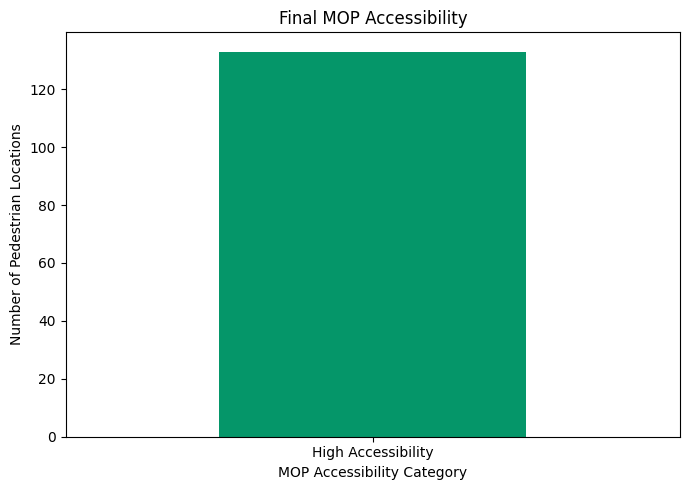

In [ ]:
# ------------------------------------------------------------
# Step 4.23: Visualise final MOP accessibility
# ------------------------------------------------------------

# Count locations in each final accessibility category.

final_accessibility_counts = (
    final_mop_results["accessibility_category"]
    .value_counts()
)

# Create a bar chart.

final_accessibility_counts.plot(
    kind="bar",
    figsize=(7, 5),
    color="#059669"
)

plt.xlabel("MOP Accessibility Category")
plt.ylabel("Number of Pedestrian Locations")
plt.title("Final MOP Accessibility")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# Prepare final MOP GeoDataFrame for mapping
# ------------------------------------------------------------

# Reset the pedestrian geometry index so it matches the
# accessibility results row-for-row.

pedestrian_geometry = (
    geoPed_data[["geometry"]]
    .reset_index(drop=True)
)

# Reset the accessibility results index as well.

mop_accessibility = mop_accessibility.reset_index(drop=True)

# Create the final GeoDataFrame.

final_mop_geo = gpd.GeoDataFrame(
    mop_accessibility.copy(),
    geometry=pedestrian_geometry["geometry"],
    crs=geoPed_data.crs
)

print("Final MOP GeoDataFrame:")
print(final_mop_geo.head())

print("\nColumns:")
print(final_mop_geo.columns)

print("\nTotal locations:", len(final_mop_geo))

Final MOP GeoDataFrame:
    latitude   longitude  open_space_score  amenity_score  tree_canopy_score  \
0 -37.813494  144.965153                 3              3                  3   
1 -37.813807  144.965167                 3              3                  3   
2 -37.811015  144.964295                 3              3                  3   
3 -37.814880  144.966088                 3              3                  3   
4 -37.818742  144.967877                 3              3                  3   

   MOP_accessibility_score accessibility_category                     geometry  
0                        9     High Accessibility  POINT (144.96515 -37.81349)  
1                        9     High Accessibility  POINT (144.96517 -37.81381)  
2                        9     High Accessibility  POINT (144.96429 -37.81102)  
3                        9     High Accessibility  POINT (144.96609 -37.81488)  
4                        9     High Accessibility  POINT (144.96788 -37.81874)  

Columns:

<div id="section-4-8" class="usecase-sub-section-heading"><b>4.8 Final MOP Accessibility Map</b></div>

<div class="usecase-body">

This section presents the final spatial map of MOP Accessibility. Each pedestrian location is displayed using its overall accessibility category, allowing the geographic distribution of High, Moderate and Low Accessibility locations to be assessed. The map provides the main spatial output for identifying patterns and locations that may warrant further investigation.
</div>

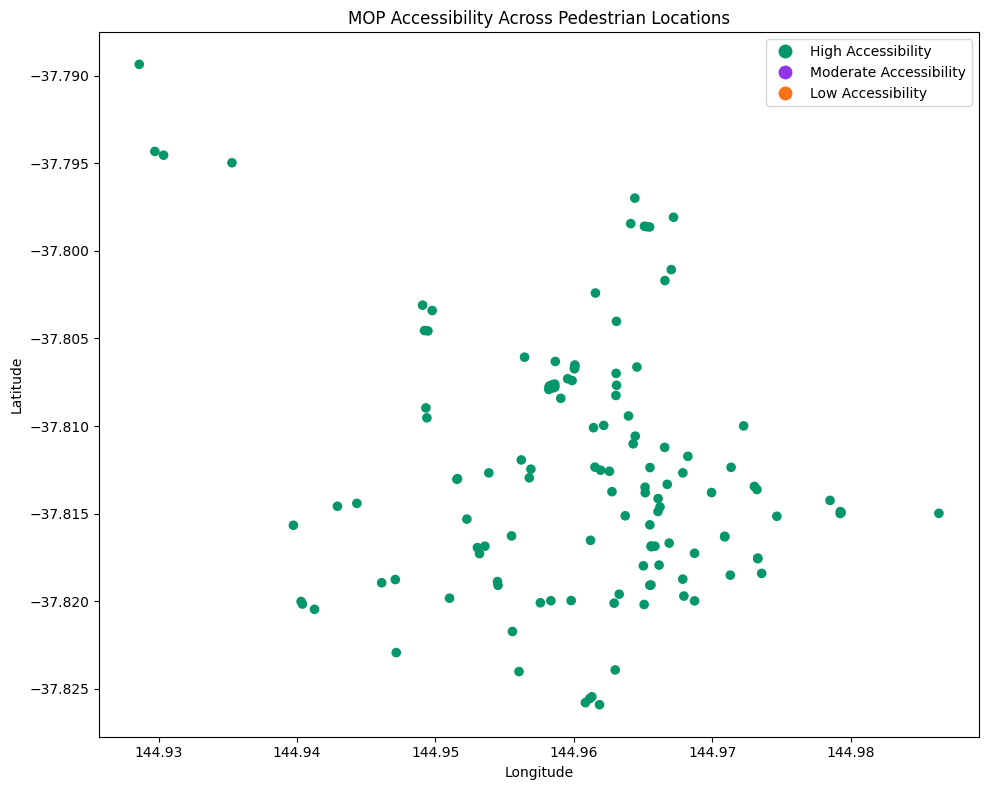

In [ ]:
# ------------------------------------------------------------
# Step 4.24: Final MOP accessibility map
# ------------------------------------------------------------

# Create the final accessibility map with readable
# longitude and latitude values.

fig, ax = plt.subplots(figsize=(10, 8))

# Apply the template colour order: green for High Accessibility
# and purple for Moderate Accessibility.
category_order = ["High Accessibility", "Moderate Accessibility", "Low Accessibility"]
category_colours = ["#059669", "#9333EA", "#F97316"]

final_mop_geo.plot(
    column="accessibility_category",
    ax=ax,
    legend=True,
    markersize=35,
    categorical=True,
    categories=category_order,
    cmap=ListedColormap(category_colours)
)

plt.title("MOP Accessibility Across Pedestrian Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Display longitude values normally instead of scientific notation
ax.ticklabel_format(
    style="plain",
    axis="x",
    useOffset=False
)

plt.tight_layout()
plt.show()

<div id="section-5" class="usecase-section-heading"><b>Step 5: Results and Findings</b></div>

<div class="usecase-body">

This step interprets the results from the accessibility analysis and summarises what they mean for the study area. The results are compared across open spaces, public amenities and tree canopy, then combined into the final accessibility categories. This section focuses on the findings, their practical meaning and the limitations that should be considered when using the results.
</div>

<div id="section-5-1" class="usecase-sub-section-heading"><b>5.1 Overall MOP Accessibility</b></div>

<div class="usecase-body">

This subsection summarises the final score distribution across the 133 pedestrian locations. The table shows how many locations fall into each accessibility category and demonstrates the overall level of accessibility identified by the scoring framework.

The final MOP accessibility assessment evaluated 133 pedestrian locations. A total of 120 locations (90.2%) achieved the maximum score of 9/9 and were classified as High Accessibility. The remaining 13 locations (9.8%) received a score of 6/9 and were classified as Moderate Accessibility. No locations were classified as Low Accessibility.

| MOP Accessibility | Score | Number of Locations | Percentage |
|---|---:|---:|---:|
| High Accessibility | 9/9 | 120 | 90.2% |
| Moderate Accessibility | 6/9 | 13 | 9.8% |
| Low Accessibility | 0–3/9 | 0 | 0% |
| **Total** | | **133** | **100%** |
</div>

<div id="section-5-2" class="usecase-sub-section-heading"><b>5.2 Accessibility to Open Spaces</b></div>

<div class="usecase-body">

This subsection summarises the distance-based results for open spaces. Comparing the average distance and accessibility categories shows how consistently nearby outdoor spaces are available around the analysed pedestrian locations.

Open-space accessibility was assessed by calculating the distance from each pedestrian location to the nearest open-space feature, including parks, playgrounds, and pedestrian tracks. The average distance to the nearest open space was 5.7 metres. All 133 pedestrian locations were classified as Excellent accessibility (<100 m).

| Measure | Result |
|---|---:|
| Average distance to nearest open space | 5.7 m |
| Excellent (<100 m) | 133 locations |
| Good (100–250 m) | 0 locations |
| Locations analysed | 133 |
</div>

<div id="section-5-3" class="usecase-sub-section-heading"><b>5.3 Accessibility to Public Amenities</b></div>

<div class="usecase-body">

This subsection summarises access to public amenities. The distance results help identify whether fountains, washrooms and seating are generally located close to pedestrian activity locations and where access is comparatively lower.

Public amenity accessibility was assessed using drinking fountains, public washrooms, and public seating. The average distance to the nearest amenity was 35.6 metres. The closest recorded distance was 0.9 metres and the furthest was 245.7 metres. A total of 122 locations were classified as Excellent accessibility (<100 m), while 11 locations were classified as Good accessibility (100–250 m).

| Measure | Result |
|---|---:|
| Average distance to nearest amenity | 35.6 m |
| Excellent (<100 m) | 122 locations |
| Good (100–250 m) | 11 locations |
| Locations analysed | 133 |
</div>

<div id="section-5-4" class="usecase-sub-section-heading"><b>5.4 Accessibility to Tree Canopy</b></div>

<div class="usecase-body">

This subsection summarises access to tree canopy. The results indicate how close greenery and potential shade are to the analysed pedestrian locations and highlight locations with comparatively greater separation from tree canopy.

Tree-canopy accessibility was assessed by calculating the distance from each pedestrian location to the nearest tree-canopy location. The average distance to the nearest tree canopy was 23.5 metres. The closest recorded distance was 0.7 metres and the furthest was 118.2 metres. A total of 131 locations were classified as Excellent accessibility (<100 m), while 2 locations were classified as Good accessibility (100–250 m).

| Measure | Result |
|---|---:|
| Average distance to nearest tree canopy | 23.5 m |
| Excellent (<100 m) | 131 locations |
| Good (100–250 m) | 2 locations |
| Locations analysed | 133 |
</div>

<div id="section-5-5" class="usecase-sub-section-heading"><b>5.5 Key Findings</b></div>

<div class="usecase-body">

This subsection brings the component results together to explain the main accessibility patterns identified by the analysis.

Overall, the analysis demonstrates a high level of accessibility across the analysed Melbourne Open Playground study area. Open spaces had the shortest average nearest-feature distance at 5.7 metres, followed by tree canopy at 23.5 metres and public amenities at 35.6 metres.

The final assessment found that 120 locations (90.2%) were classified as High Accessibility and 13 locations (9.8%) were classified as Moderate Accessibility. No locations were classified as Low Accessibility.

These findings indicate that most analysed pedestrian locations have convenient access to surrounding open spaces, public amenities, and tree canopy.
</div>

<div id="section-5-6" class="usecase-sub-section-heading"><b>5.6 Limitations</b></div>

<div class="usecase-body">

This subsection identifies factors that may affect how the accessibility results should be interpreted. Recognising these limitations helps distinguish the calculated spatial measure from a complete measure of real-world accessibility.

The accessibility results depend on the completeness and accuracy of the source datasets. The analysis uses straight-line distance to the nearest feature rather than actual pedestrian network distance, so calculated distances may not always represent the walking distance experienced by pedestrians.

The scoring system also simplifies accessibility into discrete categories and does not account for factors such as facility quality, capacity, condition, safety, or accessibility for people with different mobility requirements.

Where no corresponding amenity or tree-canopy feature was returned by the nearest-feature analysis, a score of 0 was assigned for that component. These cases should therefore be interpreted as limited or unavailable spatial matches within the datasets rather than definitive evidence that no facility or tree canopy exists at that location.
</div>

<div class="usecase-unnumbered-heading">Conclusion</div>
<div class="usecase-body">The analysis combined pedestrian locations with open-space, public amenity and tree-canopy datasets to create a geospatial accessibility assessment for outdoor fitness activities. The final results provide a consistent way to compare locations and identify areas with high or moderate accessibility.</div>

<div class="usecase-unnumbered-heading">What We Achieved</div>
<div class="usecase-body">We developed a reproducible workflow that cleans and transforms multiple Melbourne Open Data sources, calculates nearest-feature distances, converts those distances into accessibility scores and produces final summary outputs and a spatial accessibility map. The final assessment classified 120 of 133 analysed locations as High Accessibility and 13 as Moderate Accessibility.</div>

<div class="usecase-unnumbered-heading">What We Learned</div>
<div class="usecase-body">The analysis demonstrated how geospatial data can be combined across different source datasets to answer a practical planning question. It also highlighted the importance of using a projected coordinate system for distance calculations, validating missing values and interpreting score-based measures alongside the underlying spatial distances.</div>

<div class="usecase-unnumbered-heading">Observations for further opportunities</div>
<div class="usecase-body">Future work could incorporate pedestrian-network distance instead of straight-line distance, more detailed measures of facility quality and condition, accessibility requirements for different mobility needs, and more current tree-canopy information. These additions could provide a more comprehensive assessment of real-world outdoor fitness accessibility.</div>